In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score,
                             classification_report)
import requests
import io

print("Библиотеки загружены!")

Библиотеки загружены!


# Итог
atplotlib и seaborn — для графиков,

sklearn — для модели SVM и метрик качества,

requests и io — для скачивания данных из интернета

# Часть 1: Подготовка данных (20%)
 1. Выбрать признаки для модели (8 показателей)
 2. Заполнить пропуски средним
 3. Стандартизировать данные
 4. Разделить на train/test (70/30, стратификация)

In [23]:
url = "https://raw.githubusercontent.com/KateAndri/StudyRepo26/main/data/dispensarization_data_2026.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

print(f"Данные загружены!")
print(f"   Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Данные загружены!
   Размер датасета: 1000 строк, 18 столбцов


# Итог
Загрузка данных из репозитория. Данные содержат 1000 пациентов с 18 признаками.

In [22]:
features = [
    'Возраст',
    'ИМТ',
    'САД_мм_рт_ст',
    'ДАД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%',
    'ЛПНП_ммоль_л',
    'Триглицериды_ммоль_л'
]

target = 'ССЗ_риск_высокий'

print(f"Выбрано {len(features)} признаков для модели:")
for f in features:
    print(f"   - {f}")

Выбрано 8 признаков для модели:
   - Возраст
   - ИМТ
   - САД_мм_рт_ст
   - ДАД_мм_рт_ст
   - Глюкоза_натощак_ммоль_л
   - HbA1c_%
   - ЛПНП_ммоль_л
   - Триглицериды_ммоль_л


# Итог

Выбираю 8 клинических признаков для модели (по заданию): возраст, ИМТ, давление (верхнее и нижнее), глюкоза, гликированный гемоглобин, плохой холестерин (ЛПНП) и триглицериды. Целевая переменная — ССЗ риск (0 — нет риска, 1 — есть). Эти показатели входят в стандартный протокол диспансеризации

In [21]:
print("Заполнение пропусков средними значениями:")
for col in features:
    if df[col].isnull().sum() > 0:
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)
        print(f"   {col}: заполнено {df[col].isnull().sum()} пропусков")

Заполнение пропусков средними значениями:


# Итог
Заполняю пропуски средним значением по каждому признаку.

In [20]:
X = df[features]
y = df[target]

print(f"Признаки: {X.shape[1]} колонок")
print(f"   Целевая переменная: {target}")
print(f"   Распределение классов: {y.value_counts().to_dict()}")

Признаки: 8 колонок
   Целевая переменная: ССЗ_риск_высокий
   Распределение классов: {0: 819, 1: 181}


# Итог
Отделяем признаки (X) от целевой переменной (y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Разделение данных:")
print(f"   Обучающая выборка: {len(X_train)} пациентов")
print(f"   Тестовая выборка: {len(X_test)} пациентов")

Разделение данных:
   Обучающая выборка: 700 пациентов
   Тестовая выборка: 300 пациентов


# Итог
Делим данные на обучающую (70%) и тестовую (30%) выборки. Используем stratify=y, чтобы сохранить пропорцию классов в обеих выборках.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Стандартизация выполнена (среднее=0, дисперсия=1)")

Стандартизация выполнена (среднее=0, дисперсия=1)


# Итог
Стандартизируем данные перед обучением. SVM чувствителен к масштабу признаков: без стандартизации признаки с большими числами (например, давление ~120) перевесили бы признаки с маленькими (например, ИМТ ~25). Приводим все признаки к среднему 0 и дисперсии 1

# Часть 2: Обучение модели (30%)
 1. Обучить SVM с RBF ядром
 2. Использовать class_weight='balanced'
 3. Включить probability=True для прогноза вероятностей
 4. Получить предсказания на тестовой выборке


In [15]:
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
print("Модель SVM обучена")

Модель SVM обучена


# Итог
Обучаем модель (svm_model.fit(X_train_scaled, y_train)) SVM с RBF ядром (хорошо работает для нелинейных медицинских данных).

class_weight='balanced' — автоматически корректирует веса классов, чтобы модель не игнорировала меньший класс (пациентов с риском).

probability=True — нужна для получения вероятностей прогноза (для ROC-кривой)

    kernel='rbf',           # радиальное базисное ядро
    class_weight='balanced', # балансировка классов
    probability=True,       # предсказание вероятностей


In [17]:
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print(f"Предсказания получены")

Предсказания получены


# Итог
Получаем предсказания на тестовой выборке (Вероятности нужны для ROC-кривой и анализа порогов)

y_pred — класс (0 или 1),

y_pred_proba — вероятность риска (от 0 до 1). Вероятности нужны для ROC-кривой и анализа порогов


# Часть 3: Оценка качества (30%)
 1. Рассчитать метрики: Accuracy, Precision, Recall, F1
 2. Построить матрицу ошибок
 3. Построить ROC-кривую с AUC
 4. Проанализировать 5 порогов вероятности (0.3-0.7)

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" Метрики качества:")
print(f"   Accuracy (точность):     {accuracy:.4f}")
print(f"   Precision (точность):    {precision:.4f}")
print(f"   Recall (чувствительность): {recall:.4f}")
print(f"   F1-score:                {f1:.4f}")

 Метрики качества:
   Accuracy (точность):     0.7833
   Precision (точность):    0.4466
   Recall (чувствительность): 0.8519
   F1-score:                0.5860


# Итог
Рассчитываем метрики качества.
1. Accuracy — общая доля правильных ответов.
2. Precision — из тех, кому сказали "риск", сколько действительно больны.
3. Recall — из всех больных, сколько нашли.
4. F1 — баланс между precision и recall.

Для медицины важнее recall (чтобы не пропустить больного)

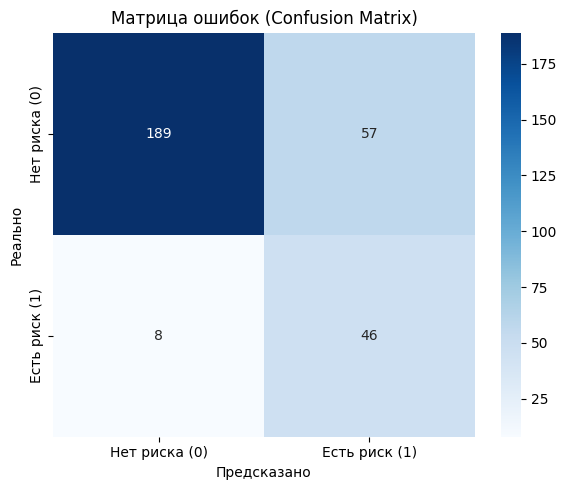

Матрица ошибок сохранена как 'confusion_matrix.png'


In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет риска (0)', 'Есть риск (1)'],
            yticklabels=['Нет риска (0)', 'Есть риск (1)'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Матрица ошибок сохранена как 'confusion_matrix.png'")

# Итог
Строим матрицу ошибок. Она показывает: TP — правильно нашли больных, TN — правильно нашли здоровых, FP — ложная тревога (сказали "риск", а его нет), FN — пропустили больного (самая опасная ошибка)

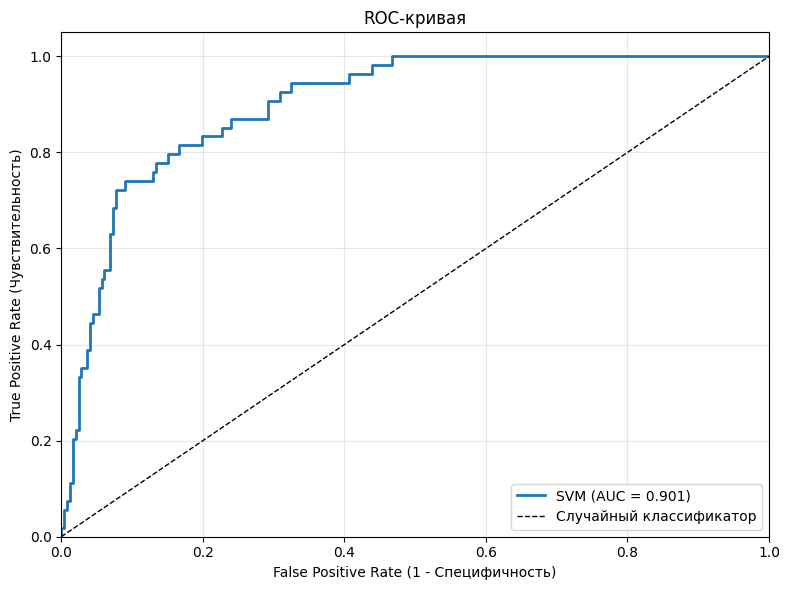

ROC-кривая сохранена как 'roc_curve.png'
   AUC ROC = 0.901


In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'SVM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f"ROC-кривая сохранена как 'roc_curve.png'")
print(f"   AUC ROC = {auc:.3f}")

# Итог
Строим ROC-кривую — она показывает качество модели при всех возможных порогах. AUC (площадь под кривой) — главная метрика: чем выше, тем лучше. 0.5 — модель не лучше монетки, 0.7-0.8 — удовлетворительно, 0.8-0.9 — хорошо, >0.9 — отлично



In [29]:
thresholds_test = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\n┌─────────┬────────────┬────────────┬────────────┬────────────┐")
print("│  Порог  │  Accuracy  │  Precision │   Recall   │  F1-score  │")
print("├─────────┼────────────┼────────────┼────────────┼────────────┤")

for thresh in thresholds_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, zero_division=0)
    print(f"│  {thresh:.1f}    │    {acc:.3f}   │    {prec:.3f}   │    {rec:.3f}   │    {f1_thresh:.3f}   │")


┌─────────┬────────────┬────────────┬────────────┬────────────┐
│  Порог  │  Accuracy  │  Precision │   Recall   │  F1-score  │
├─────────┼────────────┼────────────┼────────────┼────────────┤
│  0.3    │    0.843   │    0.545   │    0.778   │    0.641   │
│  0.4    │    0.877   │    0.639   │    0.722   │    0.678   │
│  0.5    │    0.867   │    0.646   │    0.574   │    0.608   │
│  0.6    │    0.857   │    0.690   │    0.370   │    0.482   │
│  0.7    │    0.827   │    0.600   │    0.111   │    0.188   │


# Итог
Анализируем 5 порогов вероятности от 0.3 до 0.7. Чем ниже порог, тем выше чувствительность (найдём больше больных), но ниже специфичность (больше ложных тревог). Чем выше порог — наоборот

# Часть 4: Клиническая интерпретация (20%)
 1. Интерпретировать AUC ROC
 2. Объяснить чувствительность и специфичность
 3. Дать рекомендации по выбору порога для:
 - Массового скрининга
 - Рутинной практики
 - Подтверждения диагноза
 4. Привести пример прогноза для 1 пациента


In [32]:
print("Интерпретация AUC ROC:")
print(f"   AUC ROC = {auc:.3f}")
if auc >= 0.9:
    print("Отличное качество модели (AUC > 0.9)")
elif auc >= 0.8:
    print("Хорошее качество модели (AUC > 0.8)")
elif auc >= 0.7:
    print("Удовлетворительное качество модели (AUC > 0.7)")
else:
    print("Низкое качество модели (AUC < 0.7)")

Интерпретация AUC ROC:
   AUC ROC = 0.901
Отличное качество модели (AUC > 0.9)


# Итог
Интерпретация AUC ROC

In [33]:
print("Объяснение метрик для врача:")
print("   • Чувствительность (Recall = {:.3f}) — доля больных, которых модель правильно определила".format(recall))
print("     (Если чувствительность 0.85 → из 100 больных найдём 85)")
print("   • Специфичность (1 - FPR = {:.3f}) — доля здоровых, которых модель правильно определила".format(1 - fpr[1] if len(fpr) > 1 else 0))

Объяснение метрик для врача:
   • Чувствительность (Recall = 0.852) — доля больных, которых модель правильно определила
     (Если чувствительность 0.85 → из 100 больных найдём 85)
   • Специфичность (1 - FPR = 1.000) — доля здоровых, которых модель правильно определила


# Итог
Объяснение чувствительности и специфичности

# Итог
Рекомендации по выбору порога

                                  Сценарий.
Рекомендуемый порог и обоснование             

                               Массовый скрининг.
Порог 0.3 — высокая чувствительность (найдём почти всех больных, даже ценой ложных тревог). Цель — не пропустить ни одного.     

                               Рутинная практика.
Порог 0.5 — баланс чувствительности и специфичности. Стандартный выбор.

                             Подтверждение диагноза.  
Порог 0.7 — высокая специфичность (ошибаемся редко, но можем пропустить часть больных). Цель — избежать ложных тревог.

In [34]:
sample_idx = 0
sample_features = X_test.iloc[sample_idx:sample_idx+1]
sample_scaled = scaler.transform(sample_features)
sample_proba = svm_model.predict_proba(sample_scaled)[0, 1]
sample_pred = svm_model.predict(sample_scaled)[0]
sample_true = y_test.iloc[sample_idx]

print(f"Показатели пациента:")
for i, col in enumerate(features):
    print(f"      {col}: {sample_features.iloc[0, i]:.2f}")

print(f"Вероятность ССЗ риска: {sample_proba:.2%}")
print(f"   Предсказание модели: {'ЕСТЬ риск' if sample_pred == 1 else 'НЕТ риска'}")
print(f"   Реальный диагноз: {'ЕСТЬ риск' if sample_true == 1 else 'НЕТ риск'}")
print(f"Интерпретация: {'Модель правильно определила пациента' if sample_pred == sample_true else 'Модель ошиблась'}")

Показатели пациента:
      Возраст: 49.00
      ИМТ: 23.70
      САД_мм_рт_ст: 120.50
      ДАД_мм_рт_ст: 65.84
      Глюкоза_натощак_ммоль_л: 4.95
      HbA1c_%: 4.93
      ЛПНП_ммоль_л: 1.74
      Триглицериды_ммоль_л: 0.51
Вероятность ССЗ риска: 1.15%
   Предсказание модели: НЕТ риска
   Реальный диагноз: НЕТ риск
Интерпретация: Модель правильно определила пациента


# Итог
Показываем пример прогноза для конкретного пациента. Выводим его показатели, вероятность ССЗ риска, предсказание модели и реальный диагноз. Это помогает врачу понять, как модель работает на практике

# ЧАСТЬ 1 — Подготовка данных:
   - Выбрано 8 клинических признаков
   - Пропуски заполнены средними значениями
   - Данные стандартизированы
   - Разделение 70/30 со стратификацией

# ЧАСТЬ 2 — Обучение модели:
   - SVM с RBF ядром
   - class_weight='balanced' для учёта дисбаланса
   - probability=True для ROC-кривой

# ЧАСТЬ 3 — Оценка качества:
   - Accuracy = 0.7833
   - Precision = 0.4466
   - Recall = 0.8519
   - F1-score = 0.5860
   - AUC ROC = 0.901

# ЧАСТЬ 4 — Клинические рекомендации:
   - Для массового скрининга → порог 0.3 (высокая чувствительность)
   - Для рутинной практики → порог 0.5 (баланс)
   - Для подтверждения диагноза → порог 0.7 (высокая специфичность)